In [1]:
import os

data_dir = "../data/raw/trashnet/data/dataset-resized"  #directory of the dataset
classes = [
    folder
    for folder in os.listdir(data_dir)
    if os.path.isdir(os.path.join(data_dir, folder))
] 
for c in classes:
    class_path = os.path.join(data_dir,c)
    if os.path.isdir(class_path):
        n = len(os.listdir(class_path))
        print(f"{c}: {n} images")


cardboard: 403 images
glass: 501 images
metal: 410 images
paper: 594 images
plastic: 482 images
trash: 137 images


['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


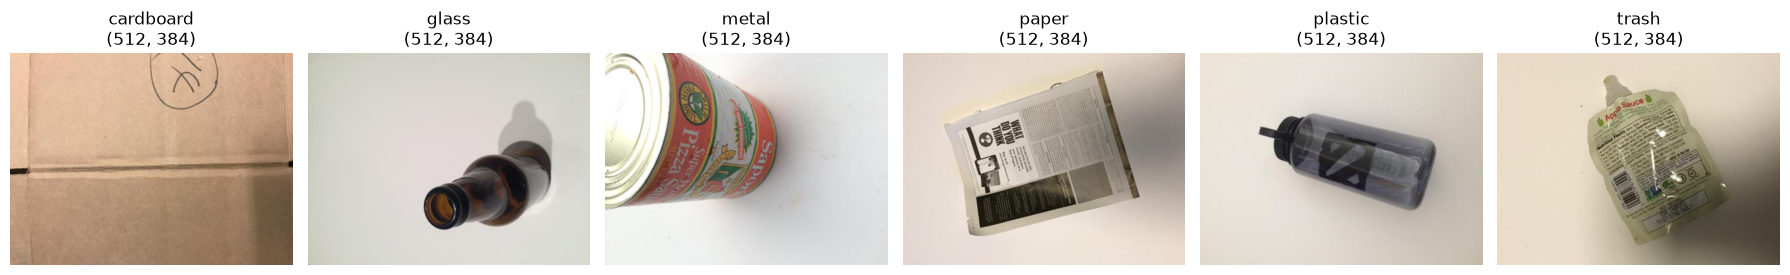

In [2]:
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(1, len(classes), figsize=(18,3))
print(classes)
for ax, c in zip(axes, classes):
    class_path = os.path.join(data_dir, c)
    first_image = os.listdir(class_path)[0]
    img = Image.open(os.path.join(class_path, first_image))
    ax.imshow(img)
    ax.set_title(f"{c}\n{img.size}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [3]:
from collections import Counter

sizes = Counter()

for c in classes:
    class_path = os.path.join(data_dir, c)
    for fname in os.listdir(class_path):
        with Image.open(os.path.join(class_path, fname)) as img:
            sizes[img.size] += 1

print(sizes)

Counter({(512, 384): 2527})


In [4]:
import torch
from torchvision import transforms
from torch.utils.data import DataLoader, random_split
from torchvision.datasets import ImageFolder

train_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

eval_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])
# import sys
# print(sys.executable)



In [5]:
full_dataset = ImageFolder(data_dir)

train_size = int(0.7*len(full_dataset))
val_size = int(0.15*len(full_dataset))
test_size = int(len(full_dataset) - train_size - val_size)

generator = torch.Generator().manual_seed(42)
train_subset, val_subset, test_subset = random_split(full_dataset, [train_size, val_size, test_size], generator=generator)

train_ds = ImageFolder(data_dir, transform = train_transforms)
val_ds = ImageFolder(data_dir, transform = eval_transforms)
test_ds = ImageFolder(data_dir, transform = eval_transforms)

train_ds = torch.utils.data.Subset(train_ds, train_subset.indices)
val_ds = torch.utils.data.Subset(val_ds, val_subset.indices)
test_ds = torch.utils.data.Subset(test_ds, test_subset.indices)


In [6]:
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=2)

print(f"Train: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}")

images, labels = next(iter(train_loader))
print(images.shape, labels.shape)

Train: 1768, Val: 379, Test: 380
torch.Size([32, 3, 224, 224]) torch.Size([32])


In [7]:
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cpu


In [8]:
model = resnet18(weights=ResNet18_Weights.DEFAULT)

for param in model.parameters():
    param.requires_grad = False

num_classes = len(classes)
model.fc = nn.Linear(model.fc.in_features, num_classes)

model = model.to(device)
print(model.fc)

Linear(in_features=512, out_features=6, bias=True)


In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.fc.parameters(), lr=0.001)

model.train()
running_loss = 0
correct = 0
total = 0

for images, labels in train_loader:
    images, labels = images.to(device), labels.to(device)

    optimizer.zero_grad()
    outputs = model(images)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()

    running_loss += loss.item() * images.size(0)
    _, predicted = torch.max(outputs,1)
    correct += (predicted == labels).sum().item()
    total += labels.size(0)

epoch_loss = running_loss / total
epoch_acc = correct / total
print(f"loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.4f}")

loss: 1.3861, Accuracy: 0.4819


In [10]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    return running_loss / total, correct / total

In [11]:
num_epochs = 10
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

Epoch 1/10 | Train Loss: 0.9559, Train Acc: 0.6816 | Val Loss: 0.8792, Val Acc: 0.6728
Epoch 2/10 | Train Loss: 0.8285, Train Acc: 0.7262 | Val Loss: 0.7672, Val Acc: 0.7045
Epoch 3/10 | Train Loss: 0.7240, Train Acc: 0.7670 | Val Loss: 0.7205, Val Acc: 0.7388
Epoch 4/10 | Train Loss: 0.7015, Train Acc: 0.7596 | Val Loss: 0.6561, Val Acc: 0.7441
Epoch 5/10 | Train Loss: 0.6378, Train Acc: 0.7755 | Val Loss: 0.7040, Val Acc: 0.7388
Epoch 6/10 | Train Loss: 0.6539, Train Acc: 0.7749 | Val Loss: 0.6665, Val Acc: 0.7441
Epoch 7/10 | Train Loss: 0.6112, Train Acc: 0.7879 | Val Loss: 0.6349, Val Acc: 0.7573
Epoch 8/10 | Train Loss: 0.5893, Train Acc: 0.8032 | Val Loss: 0.6074, Val Acc: 0.7625
Epoch 9/10 | Train Loss: 0.5788, Train Acc: 0.8133 | Val Loss: 0.6543, Val Acc: 0.7520
Epoch 10/10 | Train Loss: 0.5309, Train Acc: 0.8145 | Val Loss: 0.6406, Val Acc: 0.7652


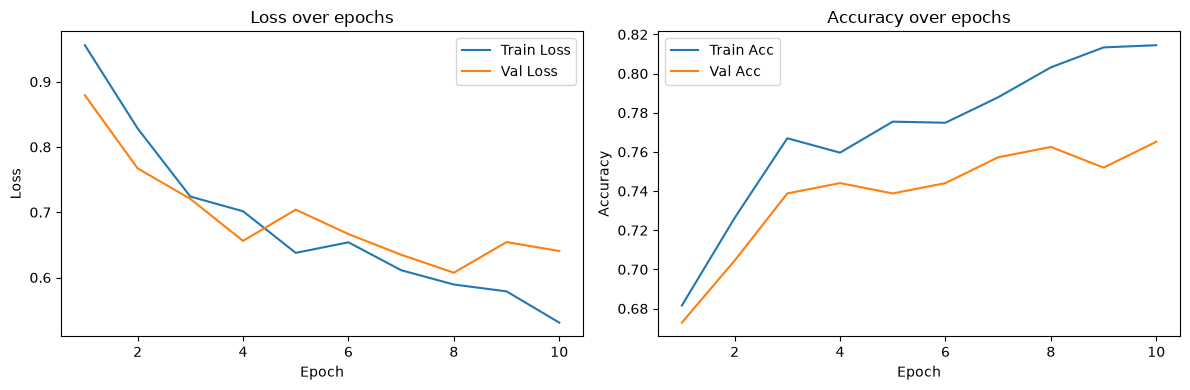

In [12]:
epochs_range = range(1, num_epochs + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_range, history["train_loss"], label="Train Loss")
axes[0].plot(epochs_range, history["val_loss"], label="Val Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].set_title("Loss over epochs")

axes[1].plot(epochs_range, history["train_acc"], label="Train Acc")
axes[1].plot(epochs_range, history["val_acc"], label="Val Acc")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].set_title("Accuracy over epochs")

plt.tight_layout()
plt.show()

In [13]:
num_more_epochs = 10

for epoch in range(num_more_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1}/{num_more_epochs} | "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

Epoch 1/10 | Train Loss: 0.5330, Train Acc: 0.8218 | Val Loss: 0.5772, Val Acc: 0.7731
Epoch 2/10 | Train Loss: 0.5321, Train Acc: 0.8133 | Val Loss: 0.5859, Val Acc: 0.7757
Epoch 3/10 | Train Loss: 0.5023, Train Acc: 0.8235 | Val Loss: 0.6091, Val Acc: 0.7704
Epoch 4/10 | Train Loss: 0.5170, Train Acc: 0.8298 | Val Loss: 0.6032, Val Acc: 0.7757
Epoch 5/10 | Train Loss: 0.4956, Train Acc: 0.8343 | Val Loss: 0.5599, Val Acc: 0.7704
Epoch 6/10 | Train Loss: 0.5083, Train Acc: 0.8162 | Val Loss: 0.6415, Val Acc: 0.7599
Epoch 7/10 | Train Loss: 0.5058, Train Acc: 0.8156 | Val Loss: 0.5718, Val Acc: 0.7810
Epoch 8/10 | Train Loss: 0.4934, Train Acc: 0.8184 | Val Loss: 0.5445, Val Acc: 0.7784
Epoch 9/10 | Train Loss: 0.4863, Train Acc: 0.8196 | Val Loss: 0.5589, Val Acc: 0.7757
Epoch 10/10 | Train Loss: 0.4615, Train Acc: 0.8428 | Val Loss: 0.5409, Val Acc: 0.7863


In [14]:
checkpoint_path = "../models/resnet18_trashnet_v1.pt"
import os
os.makedirs("../models", exist_ok=True)

torch.save({
    "model_state_dict": model.state_dict(),
    "history": history,
    "classes": classes,
}, checkpoint_path)

print(f"Saved checkpoint to {checkpoint_path}")

Saved checkpoint to ../models/resnet18_trashnet_v1.pt


In [15]:
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")

Test Loss: 0.6205, Test Accuracy: 0.7658
